# Future Price Conditional on High Activity and Heavy Imbalance

This notebook isolates one question from the transition analysis:

$$
E[\Delta P_h(t) \mid \lambda_{total}(t; W) \in \text{high bucket},\ \text{imbalance family}_t = \text{heavy}]
$$

where:

- $\Delta P_h(t) = M_{t+h} - M_t$ is the future midprice change over horizon $h$ milliseconds
- $\lambda_{total}(t; W)$ is total market-order activity over the lookback window $W$
- `imbalance family = heavy` combines both strong buy-heavy and strong sell-heavy book states

Plain-language goal: once the market is already in a high-activity and heavy-imbalance regime, measure the average future midprice move and compare the aggregate regime with its buy-heavy and sell-heavy directional sub-slices.


## 1. Parameters

These parameters intentionally mirror the other imbalance notebooks so results are comparable.


In [1]:
# Notebook parameters.

SYMBOL = "BTCUSDC"
DAYS = ["20260225"]

BOOK_REPLAY_LEVELS = 5
IMBALANCE_LEVELS = 2
N_REGIMES = 5

# Total market-order intensity window, in milliseconds.
LAMBDA_WINDOW_MS = 4000
LAMBDA_BUCKET_LABELS = ["low", "mid", "high"]

TARGET_ACTIVITY_BUCKET = "high"
TARGET_IMBALANCE_FAMILY = "heavy"
TARGET_DIRECTIONAL_LABELS = ["strong buy-heavy", "strong sell-heavy"]

# Forward midprice horizons, in milliseconds.
FUTURE_PRICE_HORIZONS_MS = [100, 250, 500, 1000, 2000, 3000, 5000]

# Maximum plotted rows per day. Highlighted high/heavy rows are always kept.
MAX_INTERACTIVE_PLOT_ROWS = 50_000

SHOW_REPLAY_PROGRESS = True
REPLAY_ON_GAP = "skip-segment"

# Optional manual inspection window for feature and order-book diagnostics.
DIAGNOSTIC_DAY = DAYS[0]
DIAGNOSTIC_START_TIME = "14:32:20"
DIAGNOSTIC_END_TIME = "14:33:00"
DIAGNOSTIC_TOP_N = 5
DIAGNOSTIC_RESAMPLE_FREQ = "100ms"
DIAGNOSTIC_DISPLAY_ROWS = 50


## 2. Setup and Data Loading

This notebook is self-contained. It loads the same cached book-level and trade tables used by the other imbalance notebooks.


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display


def find_backtester_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parents[1] if len(Path.cwd().parents) > 1 else Path.cwd()]
    for candidate in candidates:
        if (candidate / "stats").is_dir() and (candidate / "notebooks").is_dir():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate the exchange-data-backtester project root")


def resolve_day_dir(project_root: Path, *, symbol: str, day: str) -> Path:
    candidates = [
        project_root.parent / "exchange-data-recorder" / "data" / "binance" / symbol / day,
        project_root.parent / "exchange-data-recorder" / "data" / symbol / day,
        project_root.parent / "ExchangeDataRecorder" / "data" / "binance" / symbol / day,
        project_root.parent / "ExchangeDataRecorder" / "data" / symbol / day,
        project_root / "data" / "binance" / symbol / day,
        project_root / "data" / symbol / day,
    ]
    for candidate in candidates:
        candidate = candidate.resolve()
        if (candidate / "schema.json").is_file():
            return candidate
    raise FileNotFoundError(f"Could not locate a recorder day folder for {symbol}/{day}")


PROJECT_ROOT = find_backtester_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from stats.features.book import compute_depth_imbalance, compute_mid_spread
from stats.io import load_day
from stats.notebook import replay_summary
from stats.tables import get_or_build_book_levels_table, get_or_build_trades_table

loaded_days = []
book_parts = []
trade_parts = []

for day in DAYS:
    day_dir = resolve_day_dir(PROJECT_ROOT, symbol=SYMBOL, day=day)
    dataset = load_day(day_dir)
    replay_info = replay_summary(dataset, replay_on_gap=REPLAY_ON_GAP)

    if IMBALANCE_LEVELS > BOOK_REPLAY_LEVELS:
        raise ValueError("IMBALANCE_LEVELS cannot exceed BOOK_REPLAY_LEVELS")

    print(f"Loading {SYMBOL} {day}: book levels top_n={BOOK_REPLAY_LEVELS}, replay_on_gap={REPLAY_ON_GAP}", flush=True)
    book_day = get_or_build_book_levels_table(
        dataset,
        top_n=BOOK_REPLAY_LEVELS,
        on_gap=REPLAY_ON_GAP,
        show_progress=SHOW_REPLAY_PROGRESS,
    )
    print(f"Loaded {SYMBOL} {day}: {len(book_day):,} book rows", flush=True)

    print(f"Loading {SYMBOL} {day}: trades", flush=True)
    trades_day = get_or_build_trades_table(dataset)
    print(f"Loaded {SYMBOL} {day}: {len(trades_day):,} trade rows", flush=True)

    book_day = book_day.copy()
    trades_day = trades_day.copy()
    book_day["source_day"] = day
    trades_day["source_day"] = day

    book_parts.append(book_day)
    trade_parts.append(trades_day)
    loaded_days.append({"day": day, "day_dir": str(day_dir), "book_rows": len(book_day), "trade_rows": len(trades_day), **replay_info})

book_levels = pd.concat(book_parts, ignore_index=True).sort_values(["source_day", "recv_time_ms", "recv_seq"])
trades = pd.concat(trade_parts, ignore_index=True).sort_values(["source_day", "recv_time_ms", "recv_seq"])

load_summary = pd.DataFrame(loaded_days)
display(load_summary)


Loading BTCUSDC 20260225: book levels top_n=5, replay_on_gap=skip-segment
Loaded BTCUSDC 20260225: 724,751 book rows
Loading BTCUSDC 20260225: trades
Loaded BTCUSDC 20260225: 845,228 trade rows


,day,day_dir,book_rows,trade_rows,replay_on_gap,segments_total,segments_kept,segments_skipped
0,20260225,/Users/hoangdeveloper/PycharmProjects/exchange...,724751,845228,skip-segment,2,1,1


## 3. Feature Construction

We construct the shared features needed for the conditional future-price analysis:

- midprice and spread
- depth imbalance $\rho_t$
- discrete imbalance state $Z_t$
- total market-order intensity over `LAMBDA_WINDOW_MS`
- activity bucket, imbalance family, and target-regime indicators


In [3]:
def regime_labels(n_regimes: int) -> dict[int, str]:
    if n_regimes == 5:
        return {
            1: "strong sell-heavy",
            2: "mild sell-heavy",
            3: "neutral",
            4: "mild buy-heavy",
            5: "strong buy-heavy",
        }
    return {idx: f"Z={idx}" for idx in range(1, n_regimes + 1)}


def add_imbalance_features(book: pd.DataFrame, *, depth_levels: int, n_regimes: int) -> pd.DataFrame:
    out = book.copy()
    mid_spread = compute_mid_spread(out)
    depth_imbalance = compute_depth_imbalance(out, levels=[depth_levels])

    out["mid"] = mid_spread["mid"]
    out["spread"] = mid_spread["spread"]
    out["spread_bps"] = mid_spread["spread_bps"]
    out["rho"] = depth_imbalance[f"imbalance_{depth_levels}"].clip(-1, 1)

    edges = np.linspace(-1.0, 1.0, n_regimes + 1)
    labels = list(range(1, n_regimes + 1))
    out["Z"] = pd.cut(out["rho"], bins=edges, labels=labels, include_lowest=True).astype("Int64")
    out["Z_label"] = out["Z"].map(regime_labels(n_regimes)).astype("string")

    out = out.sort_values(["source_day", "epoch_id", "segment_index", "recv_time_ms", "recv_seq"]).reset_index(drop=True)
    group_cols = ["source_day", "epoch_id", "segment_index"]
    next_time = out.groupby(group_cols, dropna=False)["recv_time_ms"].shift(-1)
    out["dt_ms"] = (next_time - out["recv_time_ms"]).clip(lower=0).fillna(0)
    return out


def _count_in_window(times: np.ndarray, row_times: np.ndarray, window_ms: int) -> np.ndarray:
    right = np.searchsorted(times, row_times, side="right")
    left = np.searchsorted(times, row_times - window_ms, side="right")
    return right - left


def add_total_intensity(features: pd.DataFrame, trades: pd.DataFrame, window_ms: int) -> pd.DataFrame:
    out = features.copy()
    out[f"lambda_total_raw_{window_ms}ms"] = 0
    out[f"lambda_total_rate_{window_ms}ms"] = 0.0

    for day, idx in out.groupby("source_day", dropna=False).groups.items():
        day_trades = trades[trades["source_day"] == day]
        row_times = out.loc[idx, "recv_time_ms"].to_numpy(dtype="float64")
        trade_times = day_trades["recv_time_ms"].to_numpy(dtype="float64")
        counts = _count_in_window(trade_times, row_times, window_ms)
        out.loc[idx, f"lambda_total_raw_{window_ms}ms"] = counts
        out.loc[idx, f"lambda_total_rate_{window_ms}ms"] = counts / window_ms
    return out


def add_activity_bucket(frame: pd.DataFrame, source_col: str, bucket_col: str, *, labels: list[str]) -> pd.DataFrame:
    out = frame.copy()
    out[bucket_col] = pd.Series(pd.NA, index=out.index, dtype="string")
    valid = out[source_col].notna()
    if not valid.any():
        return out

    ranks = out.loc[valid, source_col].rank(method="first")
    out.loc[valid, bucket_col] = pd.cut(ranks, bins=len(labels), labels=labels, include_lowest=True).astype("string")
    return out


def add_imbalance_family(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    z_label = out["Z_label"].astype("string")
    out["imbalance_family"] = np.select(
        [
            z_label.str.contains("strong buy-heavy", na=False) | z_label.str.contains("strong sell-heavy", na=False),
            z_label.str.contains("mild buy-heavy", na=False) | z_label.str.contains("mild sell-heavy", na=False),
            z_label.str.contains("neutral", na=False),
        ],
        ["heavy", "mid", "neutral"],
        default=pd.NA,
    )
    out["imbalance_family"] = out["imbalance_family"].astype("string")
    return out


features = add_imbalance_features(book_levels, depth_levels=IMBALANCE_LEVELS, n_regimes=N_REGIMES)
features = add_total_intensity(features, trades, LAMBDA_WINDOW_MS)
features = add_activity_bucket(features, f"lambda_total_rate_{LAMBDA_WINDOW_MS}ms", "lambda_total_bucket", labels=LAMBDA_BUCKET_LABELS)
features = add_imbalance_family(features)
features["is_high_activity"] = features["lambda_total_bucket"].eq(TARGET_ACTIVITY_BUCKET)
features["is_high_buy_heavy"] = features["is_high_activity"] & features["Z_label"].eq("strong buy-heavy")
features["is_high_sell_heavy"] = features["is_high_activity"] & features["Z_label"].eq("strong sell-heavy")
features["is_high_heavy"] = features["is_high_activity"] & features["imbalance_family"].eq(TARGET_IMBALANCE_FAMILY)
features["joint_state"] = features["lambda_total_bucket"].astype("string") + "|" + features["imbalance_family"].astype("string")
features["is_high_strong_buy"] = features["is_high_buy_heavy"]
features["is_high_strong_sell"] = features["is_high_sell_heavy"]
features["ts"] = pd.to_datetime(features["recv_time_ms"], unit="ms", utc=True)

summary_cols = ["source_day", "recv_time_ms", "mid", "rho", "Z", "Z_label", f"lambda_total_rate_{LAMBDA_WINDOW_MS}ms", "lambda_total_bucket", "imbalance_family", "joint_state", "is_high_heavy"]
display(features[summary_cols].head())
display(features[["rho", f"lambda_total_raw_{LAMBDA_WINDOW_MS}ms", f"lambda_total_rate_{LAMBDA_WINDOW_MS}ms", "dt_ms"]].describe())


,source_day,recv_time_ms,mid,rho,Z,Z_label,lambda_total_rate_4000ms,lambda_total_bucket,imbalance_family,joint_state,is_high_heavy
0,20260225,1771981204734,64243.015,-0.432433,2,mild sell-heavy,0.0,low,mid,low|mid,False
1,20260225,1771981204834,64243.015,-0.432433,2,mild sell-heavy,0.0,low,mid,low|mid,False
2,20260225,1771981204935,64243.015,-0.487944,2,mild sell-heavy,0.0,low,mid,low|mid,False
3,20260225,1771981205035,64243.015,0.772590,5,strong buy-heavy,0.0,low,heavy,low|heavy,False
4,20260225,1771981205135,64243.015,0.525605,4,mild buy-heavy,0.0,low,mid,low|mid,False


,rho,lambda_total_raw_4000ms,lambda_total_rate_4000ms,dt_ms
count,724751.000000,724751.000000,724751.000000,724751.000000
mean,0.006707,45.089868,0.011272,110.514232
std,0.614824,70.385895,0.017596,44.524263
min,-0.999920,0.000000,0.000000,0.000000
25%,-0.524960,9.000000,0.002250,100.000000
50%,0.016246,27.000000,0.006750,100.000000
75%,0.537977,57.000000,0.014250,100.000000
max,0.999940,2884.000000,0.721000,1504.000000


## 4. Future Price Conditional on High Activity and Heavy Imbalance

For each horizon $h$, we compute:

$$
\Delta P_h(t) = M_{t+h} - M_t
$$

Then we condition on:

$$
\lambda_{total}(t; W) \in \text{high bucket} \quad \text{and} \quad \text{imbalance family}_t = \text{heavy}
$$

The table has four condition rows:

- `high_lambda_heavy`: all high-activity rows where the book is strongly imbalanced in either direction
- `high_lambda_strong_buy`: sub-slice where the high-activity, heavy-imbalance state is strong buy-heavy
- `high_lambda_strong_sell`: sub-slice where the high-activity, heavy-imbalance state is strong sell-heavy
- `other`: all rows outside `high_lambda_heavy`, used as a descriptive baseline

`mean_delta_mid` is measured in the same price units as the midprice. For `BTCUSDC`, that means USDC per BTC. A positive value means the future midprice was higher than the current midprice at that horizon.

Direction probabilities are reported separately:

- `prob_positive` means $P(\Delta P_h > 0)$
- `prob_negative` means $P(\Delta P_h < 0)$
- `prob_zero` means $P(\Delta P_h = 0)$
- `prob_expected_direction` means `prob_positive` for `high_lambda_strong_buy`, `prob_negative` for `high_lambda_strong_sell`, and `NaN` for mixed or baseline rows

This avoids reading the sell-heavy case backward: for `high_lambda_strong_sell`, the more natural directional probability is `prob_negative`.


,condition,horizon_ms,observations,mean_delta_mid,median_delta_mid,p05_delta_mid,p95_delta_mid,prob_positive,prob_negative,prob_zero,prob_expected_direction,mean_rho,mean_lambda_rate
0,high_lambda_heavy,100,113126,-0.040307,0.00,-5.4800,5.11000,0.126107,0.142593,0.731300,NaN,-0.071411,0.025538
1,high_lambda_strong_buy,100,52059,1.132770,0.00,0.0000,7.45000,0.251311,0.022763,0.725926,0.251311,0.833773,0.025876
2,high_lambda_strong_sell,100,61067,-1.040342,0.00,-6.9600,0.00000,0.019372,0.244748,0.735880,0.244748,-0.843071,0.025250
3,other,100,611624,0.013970,0.00,0.0000,0.00000,0.044845,0.043275,0.911881,NaN,0.021156,0.008634
4,high_lambda_heavy,250,113126,-0.068382,0.00,-8.3200,8.06875,0.199565,0.225536,0.574899,NaN,-0.071411,0.025538
5,high_lambda_strong_buy,250,52059,1.936462,0.00,-0.9800,11.17000,0.372500,0.057243,0.570257,0.372500,0.833773,0.025876
6,high_lambda_strong_sell,250,61067,-1.777490,0.00,-10.4200,0.32000,0.052139,0.369005,0.578856,0.369005,-0.843071,0.025250
7,other,250,611622,0.030969,0.00,-4.2400,4.44475,0.094740,0.092060,0.813200,NaN,0.021158,0.008634
8,high_lambda_heavy,500,113126,-0.081255,0.00,-10.8675,10.80000,0.253266,0.284188,0.462546,NaN,-0.071411,0.025538
9,high_lambda_strong_buy,500,52059,2.456934,0.00,-5.4600,13.85000,0.444649,0.095641,0.459709,0.444649,0.833773,0.025876


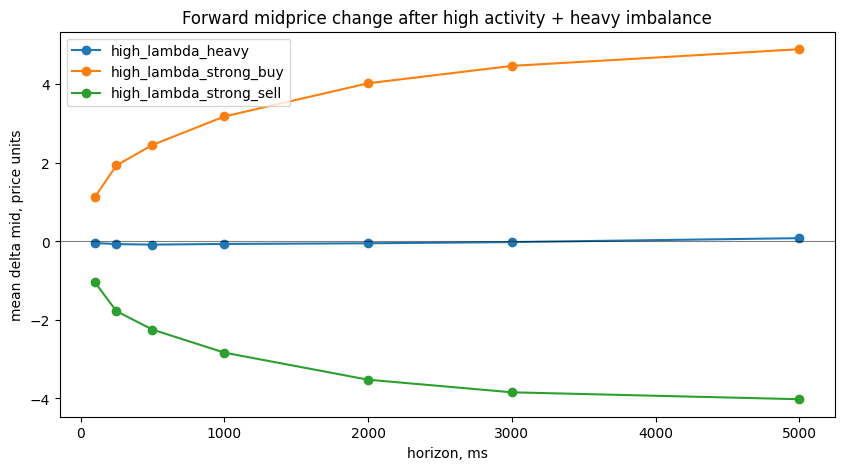

In [4]:
def add_forward_mid_changes(events: pd.DataFrame, book: pd.DataFrame, horizons_ms: list[int], *, time_col: str = "recv_time_ms") -> pd.DataFrame:
    out = events.copy()
    for horizon_ms in horizons_ms:
        out[f"delta_mid_{horizon_ms}ms"] = np.nan

    group_cols = ["source_day", "epoch_id", "segment_index"]
    for keys, event_idx in out.groupby(group_cols, dropna=False).groups.items():
        source_day, epoch_id, segment_index = keys
        book_part = book[
            (book["source_day"] == source_day)
            & (book["epoch_id"] == epoch_id)
            & (book["segment_index"] == segment_index)
        ].sort_values(["recv_time_ms", "recv_seq"])
        if book_part.empty:
            continue
        book_times = book_part["recv_time_ms"].to_numpy(dtype="float64")
        book_mid = book_part["mid"].to_numpy(dtype="float64")
        event_times = out.loc[event_idx, time_col].to_numpy(dtype="float64")
        start_mid = out.loc[event_idx, "mid"].to_numpy(dtype="float64")
        for horizon_ms in horizons_ms:
            target_times = event_times + horizon_ms
            pos = np.searchsorted(book_times, target_times, side="left")
            valid = pos < len(book_part)
            target_mid = np.full(len(event_idx), np.nan)
            target_mid[valid] = book_mid[pos[valid]]
            out.loc[np.asarray(event_idx), f"delta_mid_{horizon_ms}ms"] = target_mid - start_mid
    return out


features = add_forward_mid_changes(features, features, FUTURE_PRICE_HORIZONS_MS, time_col="recv_time_ms")

future_price_rows = []
for horizon_ms in FUTURE_PRICE_HORIZONS_MS:
    target_col = f"delta_mid_{horizon_ms}ms"
    conditional = features.dropna(subset=[target_col, "lambda_total_bucket", "imbalance_family", "Z_label"]).copy()
    condition_slices = [
        ("high_lambda_heavy", conditional["is_high_heavy"]),
        ("high_lambda_strong_buy", conditional["is_high_strong_buy"]),
        ("high_lambda_strong_sell", conditional["is_high_strong_sell"]),
        ("other", ~conditional["is_high_heavy"]),
    ]

    for condition_name, mask in condition_slices:
        part = conditional.loc[mask]
        prob_positive = (part[target_col] > 0).mean()
        prob_negative = (part[target_col] < 0).mean()
        if condition_name == "high_lambda_strong_buy":
            prob_expected_direction = prob_positive
        elif condition_name == "high_lambda_strong_sell":
            prob_expected_direction = prob_negative
        else:
            prob_expected_direction = np.nan

        future_price_rows.append(
            {
                "condition": condition_name,
                "horizon_ms": horizon_ms,
                "observations": len(part),
                "mean_delta_mid": part[target_col].mean(),
                "median_delta_mid": part[target_col].median(),
                "p05_delta_mid": part[target_col].quantile(0.05),
                "p95_delta_mid": part[target_col].quantile(0.95),
                "prob_positive": prob_positive,
                "prob_negative": prob_negative,
                "prob_zero": (part[target_col] == 0).mean(),
                "prob_expected_direction": prob_expected_direction,
                "mean_rho": part["rho"].mean(),
                "mean_lambda_rate": part[f"lambda_total_rate_{LAMBDA_WINDOW_MS}ms"].mean(),
            }
        )

future_price_conditioned = pd.DataFrame(future_price_rows)
condition_order = ["high_lambda_heavy", "high_lambda_strong_buy", "high_lambda_strong_sell", "other"]
future_price_conditioned["condition"] = pd.Categorical(future_price_conditioned["condition"], categories=condition_order, ordered=True)
future_price_conditioned = future_price_conditioned.sort_values(["horizon_ms", "condition"])

display(future_price_conditioned)

plot_data = future_price_conditioned[future_price_conditioned["condition"].isin(condition_order[:3])]
if not plot_data.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    for condition_name, part in plot_data.groupby("condition", observed=True):
        part = part.sort_values("horizon_ms")
        ax.plot(part["horizon_ms"], part["mean_delta_mid"], marker="o", label=str(condition_name))
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_title("Forward midprice change after high activity + heavy imbalance")
    ax.set_xlabel("horizon, ms")
    ax.set_ylabel("mean delta mid, price units")
    ax.legend()
    plt.show()


## 5. Interactive Price Plot With Separate Activity and Imbalance Highlights

This plot shows the midprice for the whole available period. If `DAYS` contains multiple days, the notebook produces one chart per day.

The plot separates the two concepts visually:

- the top panel shows midprice with green and red overlays for strong buy-heavy and strong sell-heavy regimes
- the bottom panel shows `lambda_total_bucket == "high"` as a translucent yellow activity band
- a live label above the chart shows the currently visible x-range, and it updates when you zoom or reset the chart

The x-axis uses human-readable UTC timestamps. Use box zoom or wheel zoom to zoom both axes. You can also type a start and end timestamp to plot only a specific window.


In [5]:
import json
import uuid

from IPython.display import HTML, display


def _sample_rows_for_plot(day_frame: pd.DataFrame, *, flag_col: str | None, max_plot_rows: int) -> pd.DataFrame:
    """Downsample while preserving flagged rows when a flag column is provided."""
    ordered = day_frame.sort_values(["ts", "recv_seq"]).reset_index(drop=True)
    if ordered.empty:
        return ordered

    base_step = max(1, len(ordered) // max(1, max_plot_rows))
    keep_pos = set(range(0, len(ordered), base_step))

    if flag_col is not None:
        highlight_mask = ordered[flag_col].fillna(False).astype(bool)
        highlight_pos = np.flatnonzero(highlight_mask.to_numpy())
        for pos in highlight_pos:
            keep_pos.add(int(pos))
            if pos > 0:
                keep_pos.add(int(pos - 1))
            if pos + 1 < len(ordered):
                keep_pos.add(int(pos + 1))

    return ordered.iloc[sorted(keep_pos)].copy()


def _format_utc_timestamp(value: pd.Timestamp) -> str:
    ts = pd.Timestamp(value)
    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")
    else:
        ts = ts.tz_convert("UTC")
    return ts.strftime("%Y-%m-%d %H:%M:%S UTC")


def _make_price_figure(day_frame: pd.DataFrame) -> tuple[go.Figure, str, str]:
    price_sample = _sample_rows_for_plot(day_frame, flag_col="is_high_buy_heavy", max_plot_rows=MAX_INTERACTIVE_PLOT_ROWS)
    activity_sample = _sample_rows_for_plot(day_frame, flag_col="is_high_activity", max_plot_rows=MAX_INTERACTIVE_PLOT_ROWS)

    fig = make_subplots(
        rows=2,
        cols=1,
        shared_xaxes=True,
        row_heights=[0.8, 0.2],
        vertical_spacing=0.04,
        specs=[[{}], [{}]],
    )

    fig.add_trace(
        go.Scattergl(
            x=price_sample["ts"],
            y=price_sample["mid"],
            mode="lines",
            name="midprice",
            line={"color": "#111827", "width": 1},
            hoverinfo="skip",
        ),
        row=1,
        col=1,
    )

    overlays = [
        ("is_high_buy_heavy", "strong buy-heavy", "#16a34a"),
        ("is_high_sell_heavy", "strong sell-heavy", "#dc2626"),
    ]

    count_parts = []
    for flag_col, label, color in overlays:
        mask = price_sample[flag_col].fillna(False).astype(bool)
        condition_count = int(day_frame[flag_col].fillna(False).sum())
        condition_share = condition_count / len(day_frame) if len(day_frame) else np.nan
        count_parts.append(f"{label}: {condition_count:,}/{len(day_frame):,} ({condition_share:.1%})")
        fig.add_trace(
            go.Scattergl(
                x=price_sample["ts"],
                y=price_sample["mid"].where(mask),
                mode="lines",
                name=f"{label} ({condition_share:.1%})",
                line={"color": color, "width": 4},
                connectgaps=False,
                hoverinfo="skip",
            ),
            row=1,
            col=1,
        )

    activity = activity_sample["is_high_activity"].fillna(False).astype(int)
    fig.add_trace(
        go.Scatter(
            x=activity_sample["ts"],
            y=activity,
            mode="lines",
            name="high activity",
            line={"color": "rgba(250, 204, 21, 0.95)", "width": 1.5, "shape": "hv"},
            fill="tozeroy",
            fillcolor="rgba(250, 204, 21, 0.25)",
            hoverinfo="skip",
            showlegend=True,
        ),
        row=2,
        col=1,
    )

    high_count = int(day_frame["is_high_activity"].fillna(False).sum())
    high_share = high_count / len(day_frame) if len(day_frame) else np.nan
    count_parts.insert(0, f"high activity: {high_count:,}/{len(day_frame):,} ({high_share:.1%})")

    fig.update_layout(
        title=f"{SYMBOL} {day_frame['source_day'].iloc[0]}: separate activity and imbalance highlights",
        dragmode="zoom",
        xaxis={
            "title": "time (UTC)",
            "type": "date",
            "tickformat": "%Y-%m-%d<br>%H:%M:%S",
            "rangeslider": {"visible": True},
        },
        xaxis2={
            "title": "time (UTC)",
            "type": "date",
            "tickformat": "%Y-%m-%d<br>%H:%M:%S",
        },
        yaxis={
            "title": "midprice",
            "tickformat": ",.12f",
            "showexponent": "none",
            "exponentformat": "none",
            "separatethousands": False,
            "fixedrange": False,
        },
        yaxis2={
            "title": "high activity",
            "range": [0, 1.05],
            "tickmode": "array",
            "tickvals": [0, 1],
            "ticktext": ["low", "high"],
            "fixedrange": True,
        },
        hovermode=False,
        legend={"orientation": "h", "yanchor": "bottom", "y": 1.02, "xanchor": "left", "x": 0},
        template="plotly_white",
        height=750,
    )

    fig.update_xaxes(matches="x", row=2, col=1)
    fig.update_yaxes(showgrid=True, row=1, col=1)
    fig.update_yaxes(showgrid=False, row=2, col=1)

    print(
        f"{SYMBOL} {day_frame['source_day'].iloc[0]}: plotted {len(price_sample):,}/{len(day_frame):,} price rows and {len(activity_sample):,} activity rows; "
        + "; ".join(count_parts)
    )
    return fig, _format_utc_timestamp(day_frame['ts'].min()), _format_utc_timestamp(day_frame['ts'].max())


def _render_price_figure_with_range_label(fig: go.Figure, *, initial_start: str, initial_end: str) -> None:
    wrapper_id = f"price-window-{uuid.uuid4().hex}"
    label_id = f"price-range-{uuid.uuid4().hex}"
    graph_html = fig.to_html(
        full_html=False,
        include_plotlyjs=True,
        config={"responsive": True, "scrollZoom": True, "displaylogo": False},
    )

    html = f"""
<div id="{wrapper_id}" style="margin-bottom: 1rem;">
  <div id="{label_id}" style="padding: 0.4rem 0.6rem; margin: 0 0 0.6rem 0; border: 1px solid #e5e7eb; border-radius: 0.5rem; background: #f9fafb; font-family: monospace;">
    Visible window: {initial_start} to {initial_end}
  </div>
  {graph_html}
</div>
<script>
(function() {{
  const root = document.getElementById({json.dumps(wrapper_id)});
  const label = document.getElementById({json.dumps(label_id)});
  if (!root || !label) {{
    return;
  }}

  const initialStart = {json.dumps(initial_start)};
  const initialEnd = {json.dumps(initial_end)};

  function formatUtc(value) {{
    const dt = new Date(value);
    if (Number.isNaN(dt.getTime())) {{
      return String(value);
    }}
    return dt.toISOString().replace('T', ' ').replace('Z', ' UTC');
  }}

  function setLabel(startValue, endValue) {{
    label.textContent = `Visible window: ${{formatUtc(startValue)}} to ${{formatUtc(endValue)}}`;
  }}

  function init() {{
    const graph = root.querySelector('.plotly-graph-div');
    if (!graph || typeof graph.on !== 'function') {{
      setTimeout(init, 50);
      return;
    }}

    setLabel(initialStart, initialEnd);

    graph.on('plotly_relayout', function(evt) {{
      const x0 = evt['xaxis.range[0]'];
      const x1 = evt['xaxis.range[1]'];
      if (x0 !== undefined && x1 !== undefined) {{
        setLabel(x0, x1);
        return;
      }}
      if (evt['xaxis.autorange']) {{
        setLabel(initialStart, initialEnd);
      }}
    }});
  }}

  init();
}})();
</script>
"""
    display(HTML(html))


def _parse_window_ts(day: str, text: str, *, default_value: pd.Timestamp) -> pd.Timestamp:
    raw = text.strip()
    if not raw:
        return default_value
    try:
        ts = pd.to_datetime(raw, utc=True)
    except Exception as exc:
        raise ValueError(f"Could not parse timestamp '{raw}'. Use a full UTC timestamp like 2026-02-25 14:32:00+00:00") from exc
    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")
    return ts


def plot_midprice_with_window_controls(frame: pd.DataFrame) -> None:
    plot_frame = frame.dropna(subset=["source_day", "ts", "mid"]).sort_values(["source_day", "ts", "recv_seq"]).copy()
    if plot_frame.empty:
        print("No price data available for plotting.")
        return

    for day, day_frame in plot_frame.groupby("source_day", sort=True, dropna=False):
        day_frame = day_frame.copy()
        day_min = day_frame["ts"].min()
        day_max = day_frame["ts"].max()

        start_box = widgets.Text(
            value=str(day_min),
            description="start",
            layout=widgets.Layout(width="360px"),
        )
        end_box = widgets.Text(
            value=str(day_max),
            description="end",
            layout=widgets.Layout(width="360px"),
        )
        apply_button = widgets.Button(description="Update plot", button_style="primary")
        output = widgets.Output()

        def _render() -> None:
            try:
                start_ts = _parse_window_ts(day, start_box.value, default_value=day_min)
                end_ts = _parse_window_ts(day, end_box.value, default_value=day_max)
            except ValueError as exc:
                output.clear_output(wait=True)
                with output:
                    print(str(exc))
                return

            if end_ts <= start_ts:
                output.clear_output(wait=True)
                with output:
                    print("End timestamp must be after start timestamp.")
                return

            window_frame = day_frame[(day_frame["ts"] >= start_ts) & (day_frame["ts"] <= end_ts)].copy()
            output.clear_output(wait=True)
            with output:
                if window_frame.empty:
                    print(f"No rows in window {start_ts} to {end_ts} for {day}.")
                else:
                    fig, visible_start, visible_end = _make_price_figure(window_frame)
                    _render_price_figure_with_range_label(fig, initial_start=visible_start, initial_end=visible_end)

        def _on_click(_button) -> None:
            _render()

        apply_button.on_click(_on_click)
        controls = widgets.HBox([start_box, end_box, apply_button])
        display(widgets.VBox([widgets.HTML(f"<b>{SYMBOL} {day}</b>"), controls, output]))
        _render()


plot_midprice_with_window_controls(features)


## 6. Order Book Window Diagnostics

This optional section inspects one short window in more detail. It is useful when imbalance alone is not enough: a near-neutral imbalance can still happen when both sides of the book are thin.

The diagnostics use the `DIAGNOSTIC_*` parameters from the first section. The feature table shows the regime variables in the selected window. The plot then shows three directly readable panels:

- best bid, best ask, and midprice
- total bid and ask depth over the first `DIAGNOSTIC_TOP_N` levels
- depth imbalance over the same levels


In [6]:
def _diagnostic_window_bounds() -> tuple[str, pd.Timestamp, pd.Timestamp]:
    day = str(DIAGNOSTIC_DAY)
    start = pd.Timestamp(f"{day} {DIAGNOSTIC_START_TIME}", tz="UTC")
    end = pd.Timestamp(f"{day} {DIAGNOSTIC_END_TIME}", tz="UTC")
    if end <= start:
        raise ValueError("DIAGNOSTIC_END_TIME must be after DIAGNOSTIC_START_TIME")
    return day, start, end


def display_feature_matrix_window(frame: pd.DataFrame, *, day: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    feature_cols = [
        "ts",
        "recv_time_ms",
        "mid",
        "rho",
        "Z",
        "Z_label",
        f"lambda_total_rate_{LAMBDA_WINDOW_MS}ms",
        f"lambda_total_raw_{LAMBDA_WINDOW_MS}ms",
        "lambda_total_bucket",
        "imbalance_family",
        "is_high_activity",
        "is_high_buy_heavy",
        "is_high_sell_heavy",
    ]
    available_cols = [col for col in feature_cols if col in frame.columns]
    window = frame.loc[
        (frame["source_day"] == day)
        & (frame["ts"] >= start)
        & (frame["ts"] <= end),
        available_cols,
    ].copy()

    print(f"Feature rows in diagnostic window: {len(window):,}")
    display(window.head(DIAGNOSTIC_DISPLAY_ROWS))
    return window


def plot_orderbook_summary_window(
    book: pd.DataFrame,
    *,
    day: str,
    start: pd.Timestamp,
    end: pd.Timestamp,
    top_n: int = 5,
    resample_freq: str | None = "100ms",
) -> pd.DataFrame | None:
    required = ["source_day", "ts", "recv_seq"]
    for level in range(1, top_n + 1):
        required.extend([f"bid{level}_price", f"bid{level}_qty", f"ask{level}_price", f"ask{level}_qty"])
    missing = [col for col in required if col not in book.columns]
    if missing:
        raise KeyError(f"Missing book columns for top_n={top_n}: {missing[:8]}")

    window = book.loc[
        (book["source_day"] == day)
        & (book["ts"] >= start)
        & (book["ts"] <= end),
        required,
    ].copy()

    if window.empty:
        print("No book rows in that window.")
        return None

    window = window.sort_values(["ts", "recv_seq"]).reset_index(drop=True)
    raw_rows = len(window)

    if resample_freq is not None:
        keep_cols = [col for col in required if col != "source_day"]
        window = (
            window[keep_cols]
            .set_index("ts")
            .resample(resample_freq)
            .last()
            .dropna(subset=["bid1_price", "ask1_price"])
            .reset_index()
        )

    bid_cols = [f"bid{i}_qty" for i in range(1, top_n + 1)]
    ask_cols = [f"ask{i}_qty" for i in range(1, top_n + 1)]

    window["mid"] = (window["bid1_price"] + window["ask1_price"]) / 2.0
    window["bid_depth"] = window[bid_cols].sum(axis=1)
    window["ask_depth"] = window[ask_cols].sum(axis=1)
    depth_total = (window["bid_depth"] + window["ask_depth"]).replace(0, np.nan)
    window["depth_imbalance"] = (window["bid_depth"] - window["ask_depth"]) / depth_total

    fig = make_subplots(
        rows=3,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.04,
        row_heights=[0.45, 0.3, 0.25],
        subplot_titles=("Best prices", f"Depth over top {top_n} levels", "Depth imbalance"),
    )

    fig.add_trace(
        go.Scatter(x=window["ts"], y=window["mid"], mode="lines", name="mid", line={"color": "black", "width": 2}),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Scatter(x=window["ts"], y=window["bid1_price"], mode="lines", name="best bid", line={"color": "#16a34a", "width": 1.5}),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Scatter(x=window["ts"], y=window["ask1_price"], mode="lines", name="best ask", line={"color": "#dc2626", "width": 1.5}),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Scatter(x=window["ts"], y=window["bid_depth"], mode="lines", name=f"bid depth ({top_n} levels)", line={"color": "#16a34a", "width": 1.5}),
        row=2,
        col=1,
    )
    fig.add_trace(
        go.Scatter(x=window["ts"], y=window["ask_depth"], mode="lines", name=f"ask depth ({top_n} levels)", line={"color": "#dc2626", "width": 1.5}),
        row=2,
        col=1,
    )
    fig.add_trace(
        go.Scatter(x=window["ts"], y=window["depth_imbalance"], mode="lines", name="depth imbalance", line={"color": "#7c3aed", "width": 1.5}),
        row=3,
        col=1,
    )

    fig.update_layout(
        title=f"{day} order book diagnostic window: {start} to {end}",
        template="plotly_white",
        height=900,
        dragmode="zoom",
        hovermode="x unified",
        legend={"orientation": "h", "yanchor": "bottom", "y": 1.03, "xanchor": "left", "x": 0},
    )
    fig.update_xaxes(title="time (UTC)", rangeslider={"visible": True}, row=3, col=1)
    fig.update_yaxes(title="price", tickformat=",.12f", row=1, col=1)
    fig.update_yaxes(title="quantity", row=2, col=1)
    fig.update_yaxes(title="imbalance", range=[-1, 1], row=3, col=1)

    print(f"Book rows in diagnostic window: {raw_rows:,} raw, {len(window):,} plotted")
    fig.show()
    return window


diagnostic_day, diagnostic_start, diagnostic_end = _diagnostic_window_bounds()
diagnostic_features = display_feature_matrix_window(features, day=diagnostic_day, start=diagnostic_start, end=diagnostic_end)
diagnostic_book = plot_orderbook_summary_window(
    book_levels,
    day=diagnostic_day,
    start=diagnostic_start,
    end=diagnostic_end,
    top_n=DIAGNOSTIC_TOP_N,
    resample_freq=DIAGNOSTIC_RESAMPLE_FREQ,
)


Feature rows in diagnostic window: 400


,ts,recv_time_ms,mid,rho,Z,Z_label,lambda_total_rate_4000ms,lambda_total_raw_4000ms,lambda_total_bucket,imbalance_family,is_high_activity,is_high_buy_heavy,is_high_sell_heavy
425682,2026-02-25 14:32:20.035000+00:00,1772029940035,66771.275,0.296038,4,mild buy-heavy,0.02975,119,high,mid,True,False,False
425683,2026-02-25 14:32:20.135000+00:00,1772029940135,66774.265,0.819373,5,strong buy-heavy,0.03000,120,high,heavy,True,True,False
425684,2026-02-25 14:32:20.234000+00:00,1772029940234,66774.265,0.635597,5,strong buy-heavy,0.02800,112,high,heavy,True,True,False
425685,2026-02-25 14:32:20.334000+00:00,1772029940334,66774.265,0.374399,4,mild buy-heavy,0.02525,101,high,mid,True,False,False
425686,2026-02-25 14:32:20.434000+00:00,1772029940434,66774.265,0.997760,5,strong buy-heavy,0.02200,88,high,heavy,True,True,False
425687,2026-02-25 14:32:20.534000+00:00,1772029940534,66774.265,0.808259,5,strong buy-heavy,0.02125,85,high,heavy,True,True,False
425688,2026-02-25 14:32:20.635000+00:00,1772029940635,66779.645,0.925869,5,strong buy-heavy,0.02200,88,high,heavy,True,True,False
425689,2026-02-25 14:32:20.735000+00:00,1772029940735,66781.995,0.999091,5,strong buy-heavy,0.02400,96,high,heavy,True,True,False
425690,2026-02-25 14:32:20.834000+00:00,1772029940834,66787.195,0.755454,5,strong buy-heavy,0.02375,95,high,heavy,True,True,False
425691,2026-02-25 14:32:20.934000+00:00,1772029940934,66787.195,0.668498,5,strong buy-heavy,0.02375,95,high,heavy,True,True,False


Book rows in diagnostic window: 400 raw, 400 plotted


## 7. Interpretation Notes

Use this section after running the notebook.

Things to check:

- Does `high_lambda_heavy` have a different `mean_delta_mid` from `other`?
- Do `high_lambda_strong_buy` and `high_lambda_strong_sell` have opposite signs?
- For `high_lambda_strong_buy`, read `prob_positive` and `prob_expected_direction` as the chance of an upward move.
- For `high_lambda_strong_sell`, read `prob_negative` and `prob_expected_direction` as the chance of a downward move.
- Does the effect get stronger or decay as the horizon increases?
- Is the directional probability meaningfully above the baseline, or is the mean driven by a small number of large moves?
- Are there enough observations in each directional sub-slice to trust the summary?
- In the interactive price plot, do the highlighted regimes cluster around visually meaningful price moves or only around noisy flickers?
